In [1]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
%matplotlib inline

In [3]:
with open('data/Spring XD Sprints 67.csv') as f:
    lines = list(csv.reader(f))
    sprint_df = pd.read_csv('data/Spring XD Sprints 67.csv')

In [4]:
with open('data/Spring XD Issues 1992.csv') as f:
    issue_lines = list(csv.reader(f))
    issue_df = pd.read_csv('data/Spring XD Issues 1992.csv')

In [5]:
with open('data/Spring XD Issues Summary 2861.csv') as f:
    summary_lines = list(csv.reader(f))
    summary_df = pd.read_csv('data/Spring XD Issues Summary 2861.csv')

In [6]:
#Sprints
header, values = lines[0], lines[1:]

In [7]:
print(header)

['\ufeffsprintId', 'sprintName', 'sprintState', 'sprintStartDate', 'sprintEndDate', 'sprintCompleteDate', 'totalNumberOfIssues', 'completedIssuesCount', 'issuesNotCompletedInCurrentSprint', 'puntedIssues', 'issuesCompletedInAnotherSprint', 'issueKeysAddedDuringSprint', 'completedIssuesInitialEstimateSum', 'completedIssuesEstimateSum', 'puntedIssuesInitialEstimateSum', 'puntedIssuesEstimateSum', 'issuesNotCompletedInitialEstimateSum', 'issuesNotCompletedEstimateSum', 'issuesCompletedInAnotherSprintInitialEstimateSum', 'issuesCompletedInAnotherSprintEstimateSum', 'NoOfDevelopers', 'SprintLength']


In [8]:
print(values[0])

['1', 'Sprint 1', 'CLOSED', '15-Apr-13', '29-Apr-13', '6-May-13', '23', '11', '0', '6', '0', '15', '12', '18', '7', '9', '0', '0', '0', '0', '8', '21']


In [9]:
# Spring XD Issues
header, values = issue_lines[0], issue_lines[1:]

In [10]:
print(header)

['\ufeffkey', 'issueType', 'sprint', 'status', 'summary', 'description', 'storyPoint', 'priority', 'watchcount', 'fixVersions', 'affectedVersions', 'assignee', 'creator', 'reporter', 'commentCount', 'votes', 'issueLinks', 'blockedBy', 'blocks', 'dependedOnBy', 'dependedOn', 'subtasks']


In [11]:
print(values[0])

['XD-6', 'Story', '1', 'Done', 'Channel Registry', 'null', '3', '4', '2', '1', '0', 'David Turanski', 'Mark Pollack', 'Mark Pollack', '1', '0', '1', '0', '0', '0', '0', '2']


In [12]:
# Spring XD Issues Summary
header, values = summary_lines[0], summary_lines[1:]

In [13]:
print(header)

['\ufeffprojectID', 'sprintId', 'status', 'storyId', 'issueKey', 'summary', 'priorityId', 'assignee', 'initialStoryPoint', 'currentStoryPoint']


In [14]:
print(values[0])

['43', '1', 'Completed', '48125', 'XD-6', 'Channel Registry', '4', 'dturanski', '0', '3']


In [16]:
#Spring velocity Trend Analysis
# Sprint velocity is typically calculated based on the number of completed issues within a sprint and the duration of the sprint
#   Plot sprint velocity (completed issues count) over time (sprint start date or end date) to visualize the trend in team productivity.
#   Identify fluctuations or patterns in sprint velocity over multiple sprints.
#  Calculate metrics such as average velocity, velocity variance, and sprint success rate to assess team performance.

In [17]:
sprint_df['sprintStartDate'] = pd.to_datetime(sprint_df['sprintStartDate'], format='%d-%b-%y')

In [18]:
sprint_df['sprintCompleteDate'] = pd.to_datetime(sprint_df['sprintCompleteDate'], format='%d-%b-%y')

In [19]:
sprint_df['sprint_length'] = (sprint_df['sprintCompleteDate'] - sprint_df['sprintStartDate']).dt.days

In [20]:
sprint_df['sprint_velocity'] = (sprint_df['completedIssuesCount'] / sprint_df['sprint_length'])
print(sprint_df['sprint_velocity'])

0     0.523810
1     1.125000
2     3.000000
3     3.500000
4     3.666667
        ...   
61    1.090909
62    0.416667
63    0.125000
64    0.750000
65    0.700000
Name: sprint_velocity, Length: 66, dtype: float64


In [21]:
sprint_df['sprint'] = range(1, len(sprint_df) + 1)

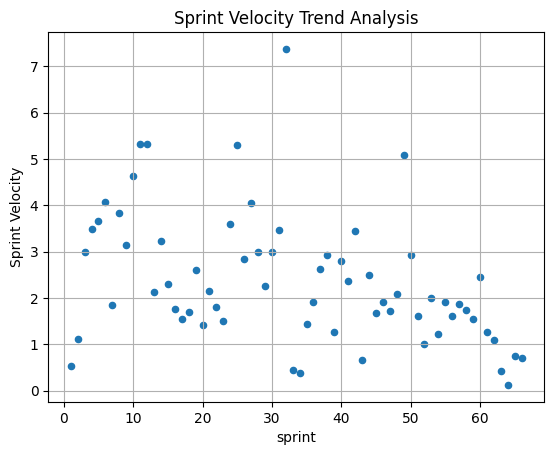

In [22]:
sprint_df.plot(x='sprint', y='sprint_velocity', kind='scatter')
plt.xlabel('sprint')
plt.ylabel('Sprint Velocity')
plt.title('Sprint Velocity Trend Analysis')
plt.grid(True)
plt.show()

In [23]:
# Average Velocity 
average_sprint_velocity = sprint_df['sprint_velocity'].mean(); 
print(average_sprint_velocity)
sprint_velocity_variance = sprint_df['sprint_velocity'].var();
print(sprint_velocity_variance)

2.373191156837886
1.970324983619671


In [24]:
# Sprint Success Rate = ( Number of successful sprint / Total Number of Sprint ) * 100;
# successful sprints those sprints where the sprintCompleteDate is on or before the planned sprintEndDate.

In [25]:
sprint_df['sprintEndDate'] = pd.to_datetime(sprint_df['sprintEndDate'], format='%d-%b-%y')
sprint_df['sprint_slippage'] = (sprint_df['sprintCompleteDate'] - sprint_df['sprintEndDate']).dt.days

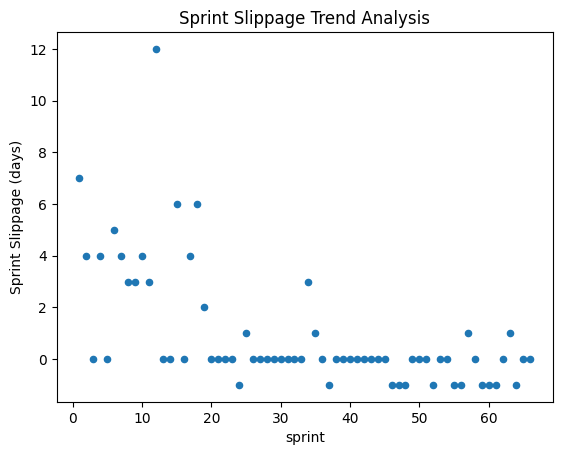

In [26]:
# success of each sprint ( how each sprint complated according to the time they stated to end)
sequential_ticks = np.arange(1, 66 + 1)

sprint_df.plot(x='sprint', y='sprint_slippage', kind='scatter')
plt.xlabel('sprint')
plt.ylabel('Sprint Slippage (days)')
plt.title('Sprint Slippage Trend Analysis')
#plt.xticks(range(len(committed_issues_df)), sequential_ticks, rotation=90)  # Use sequential ticks for the x-axis
#plt.grid(True)
plt.show()

In [27]:
# Sprint Success Rate = ( Number of successful sprint / Total Number of Sprint ) * 100;
total_number_of_sprint = len(sprint_df['sprintId']) 
number_of_successful_sprint = (sprint_df['sprint_slippage'] <= 0).sum()
print(number_of_successful_sprint)

47


In [28]:
#sprint succes Rate
sprint_success_rate = (number_of_successful_sprint / total_number_of_sprint ) * 100;
print(sprint_success_rate)

71.21212121212122


In [29]:
# 2. Team Composition Analyssis

In [30]:
# Sprint Velocity VS Number of Developers
new_df = sprint_df[['sprint_velocity', 'NoOfDevelopers']]

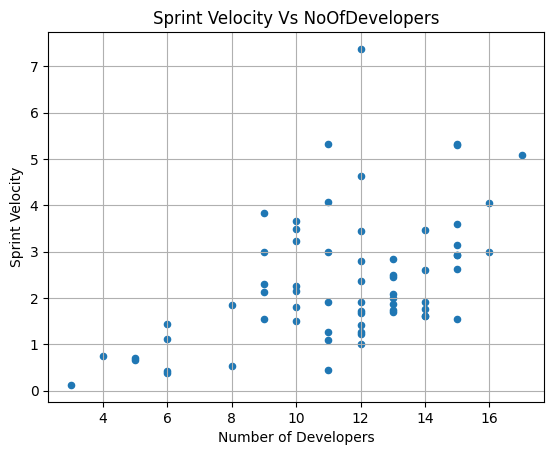

In [31]:
new_df.plot(x='NoOfDevelopers', y='sprint_velocity', kind='scatter')
plt.xlabel('Number of Developers')
plt.ylabel('Sprint Velocity')
plt.title('Sprint Velocity Vs NoOfDevelopers')
plt.grid(True)
plt.show()

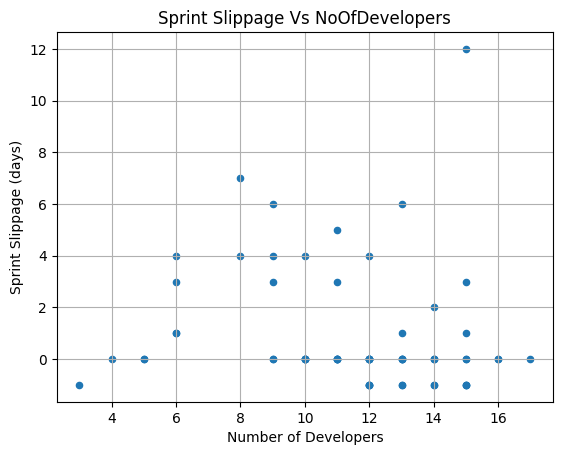

In [32]:
# Date_complate_minus_end vs No Developers
sprint_df.plot(x ='NoOfDevelopers', y='sprint_slippage', kind='scatter')
plt.xlabel('Number of Developers')
plt.ylabel('Sprint Slippage (days)')
plt.title('Sprint Slippage Vs NoOfDevelopers')
plt.grid(True)
plt.show()

In [33]:
# 3. Sprint Length Analysis:

In [34]:
#    Compare sprint velocity for different sprint lengths (e.g., short vs. long sprints).
#    Plot sprint velocity against sprint length to identify the optimal sprint duration for maximizing productivity.

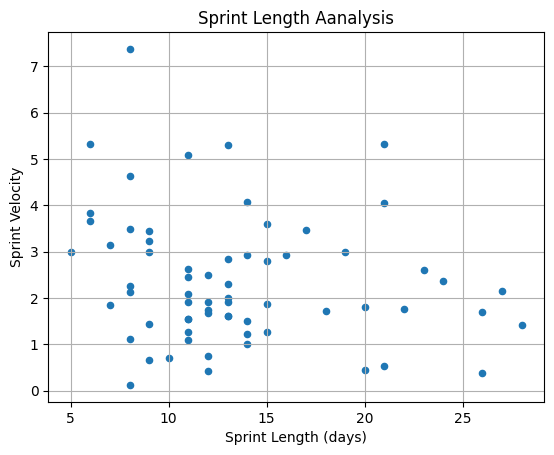

In [35]:
sprint_df.plot(x='sprint_length', y='sprint_velocity', kind='scatter')
plt.xlabel('Sprint Length (days)')
plt.ylabel('Sprint Velocity')
plt.title('Sprint Length Aanalysis')
plt.grid(True)
plt.show()

In [36]:
# 4. Issue Type Analysis:
#    Analyze the distribution of issue types (e.g., bugs, user stories, tasks) within each sprint.

In [37]:
issue_counts = issue_df.groupby(['sprint', 'issueType']).size().unstack(fill_value=0)

In [38]:
print(issue_counts)

issueType  Bug  Improvement  Story  Technical task
sprint                                            
1            1            0     10               6
3            0            0     10               0
4            0            0     15               0
5            0            0     27               2
6            2            0     31               0
...        ...          ...    ...             ...
102          6            0      6               0
103          1            1      3               0
106          2            0      0               0
107          5            4      0               0
108          3            4      0               0

[66 rows x 4 columns]


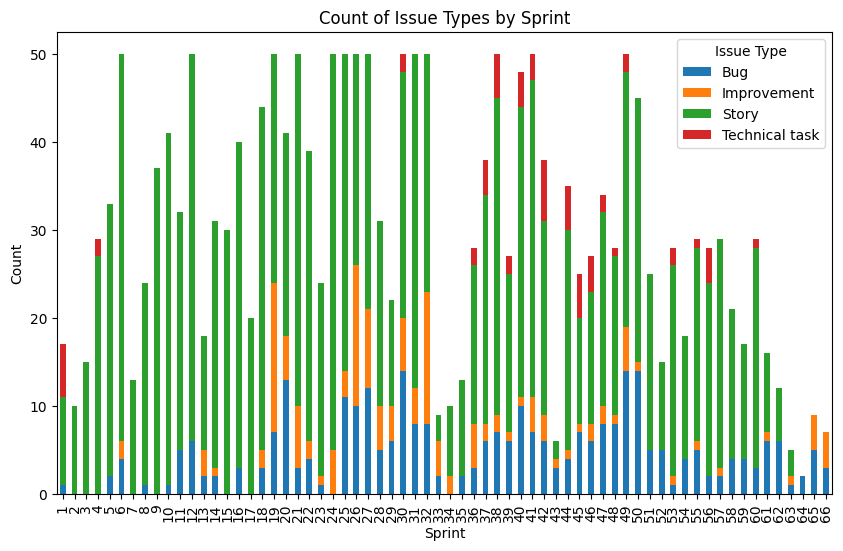

In [40]:
# Plot the counts for each issueType by sprint
sequential_ticks = np.arange(1, 66 + 1)
issue_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Sprint')
plt.ylabel('Count')
plt.title('Count of Issue Types by Sprint')
plt.legend(title='Issue Type')
plt.xticks(range(len(issue_counts)), sequential_ticks, rotation=90)  # Use sequential ticks for the x-axis
plt.show()

In [41]:
# 5 Completion vs. Commitment Analysis:
#    Compare the total number of committed issues (planned for the sprint) with the number of completed issues.
#    Plot completed issues count vs. committed issues count to assess sprint commitment accuracy and identify potential overcommitment or undercommitment.

In [42]:
# Filter the dataset to include only the relevant columns for committed issues
committed_issues_df = sprint_df[['sprintId', 'totalNumberOfIssues', 'completedIssuesCount']]

In [43]:
#  percentage of completed issues compared to total issues

In [45]:
committed_issues_df.loc[:, 'completionPercentage'] = (committed_issues_df['completedIssuesCount'] / committed_issues_df['totalNumberOfIssues']) * 100

In [46]:
print(committed_issues_df)

    sprintId  totalNumberOfIssues  completedIssuesCount  completionPercentage
0          1                   23                    11             47.826087
1          3                   26                     9             34.615385
2          4                   23                    15             65.217391
3          5                   48                    28             58.333333
4          6                   35                    22             62.857143
..       ...                  ...                   ...                   ...
61       102                   58                    12             20.689655
62       103                   79                     5              6.329114
63       106                    8                     1             12.500000
64       107                   11                     9             81.818182
65       108                    7                     7            100.000000

[66 rows x 4 columns]


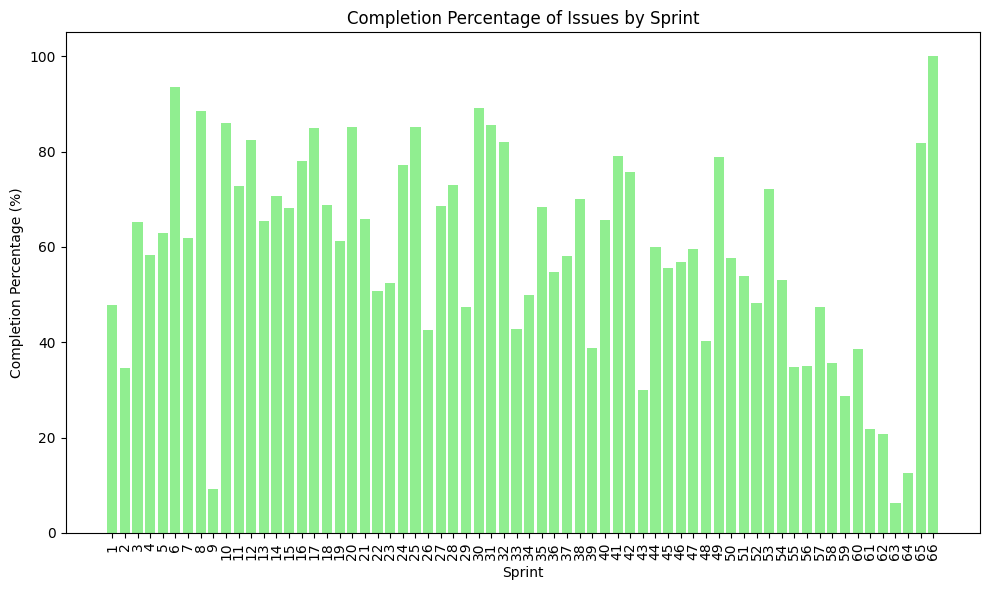

In [49]:
sequential_ticks = np.arange(1, 66 + 1)

# Plot the data with sequential ticks
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(range(len(committed_issues_df)), committed_issues_df['completionPercentage'], color='lightGreen')  # Adjust width as needed
plt.xlabel('Sprint')
plt.ylabel('Completion Percentage (%)')
plt.title('Completion Percentage of Issues by Sprint')
plt.xticks(range(len(committed_issues_df)), sequential_ticks, rotation=90)  # Use sequential ticks for the x-axis
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

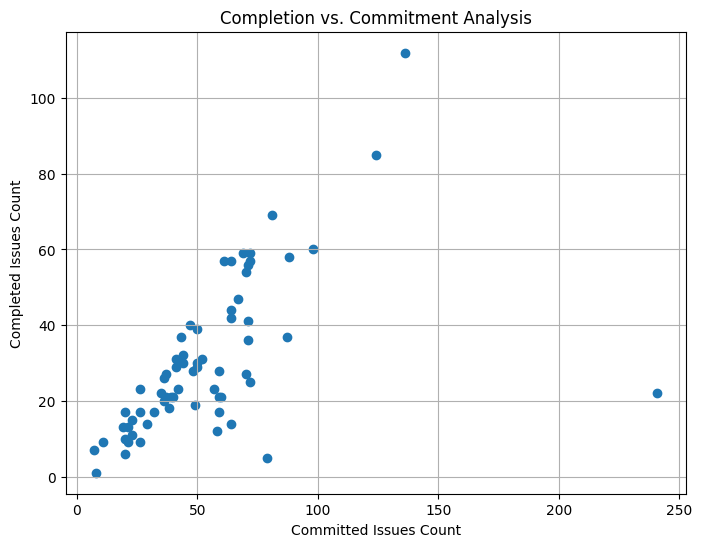

In [56]:
# Plot completed issues count vs. committed issues count
plt.figure(figsize=(8, 6))
plt.scatter(committed_issues_df['totalNumberOfIssues'], committed_issues_df['completedIssuesCount'])
plt.xlabel('Committed Issues Count')
plt.ylabel('Completed Issues Count')
plt.title('Completion vs. Commitment Analysis')
plt.grid(True)
plt.show()

In [134]:
# 6. Issue Estimation Analysis:

#    Analyze the relationship between estimated and actual effort for completed issues.
#    Plot completed issues estimate sum against completed issues initial estimate sum to assess estimation accuracy and identify discrepancies.

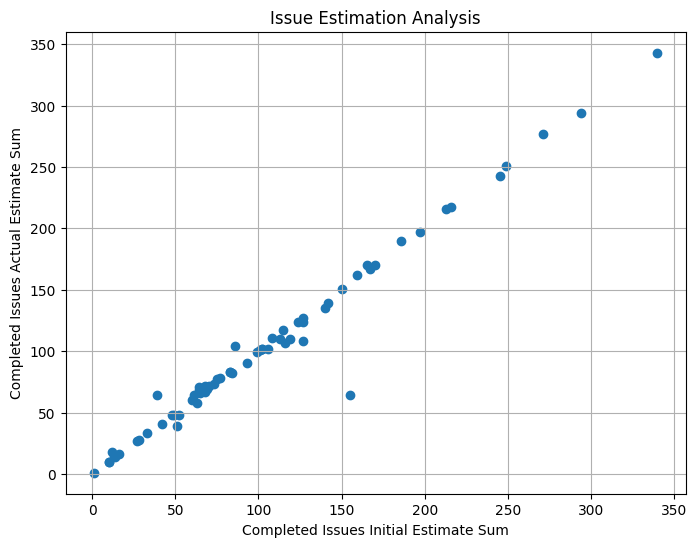

In [135]:
estimate_sum_initial = sprint_df['completedIssuesInitialEstimateSum']
estimate_sum_actual = sprint_df['completedIssuesEstimateSum']

# Plot completed issues estimate sum against completed issues initial estimate sum
plt.figure(figsize=(8, 6))
plt.scatter(estimate_sum_initial, estimate_sum_actual)
plt.xlabel('Completed Issues Initial Estimate Sum')
plt.ylabel('Completed Issues Actual Estimate Sum')
plt.title('Issue Estimation Analysis')
plt.grid(True)
plt.show()

In [146]:
# 7. Cycle Time Analysis:
new_df = sprint_df[['sprintStartDate', 'sprintCompleteDate']].copy()
new_df['sprintStartDate'] = pd.to_datetime(new_df['sprintStartDate'], format='%d-%b-%y')
new_df['sprintCompleteDate'] = pd.to_datetime(new_df['sprintCompleteDate'], format='%d-%b-%y')
new_df['CycleTime'] = new_df['sprintCompleteDate'] - new_df['sprintStartDate']

Mean Cycle Time: 13.469696969696969 days
Median Cycle Time: 12.0 days


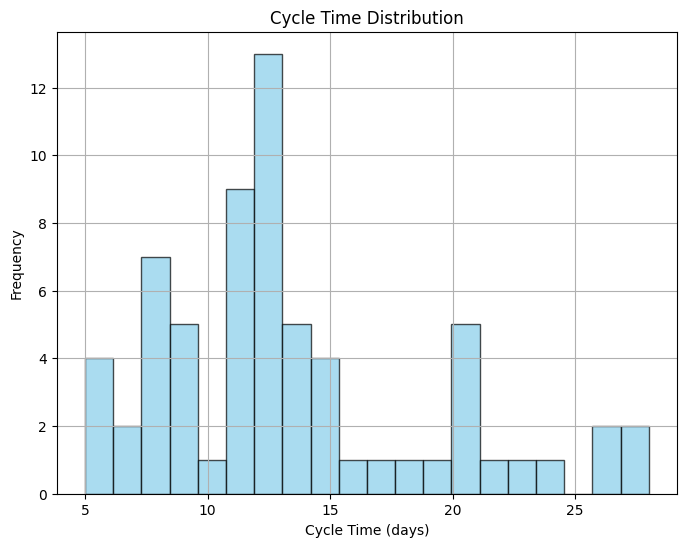

In [147]:

# Optionally, analyze cycle time distribution
cycle_time_distribution = new_df['CycleTime'].dt.days
cycle_time_mean = cycle_time_distribution.mean()
cycle_time_median = cycle_time_distribution.median()

print(f"Mean Cycle Time: {cycle_time_mean} days")
print(f"Median Cycle Time: {cycle_time_median} days")

# Optionally, plot cycle time distribution
plt.figure(figsize=(8, 6))
plt.hist(cycle_time_distribution, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Cycle Time (days)')
plt.ylabel('Frequency')
plt.title('Cycle Time Distribution')
plt.grid(True)
plt.show()